<a href="https://colab.research.google.com/github/samuelbmenezes7/ProjetoTDAH-EyeTracking/blob/main/Projeto_peso_galinha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A carregar o modelo de Visão Computacional (YOLOv8)...

A extrair geometria 3D de 7 vídeos. Por favor, aguarde...

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 BASE DE DADOS ALIMENTADA COM SUCESSO!
 Precisão do Modelo Polinomial (R²): 88.5%
 O modelo foi guardado como 'modelo_zootecnico.pkl'.
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


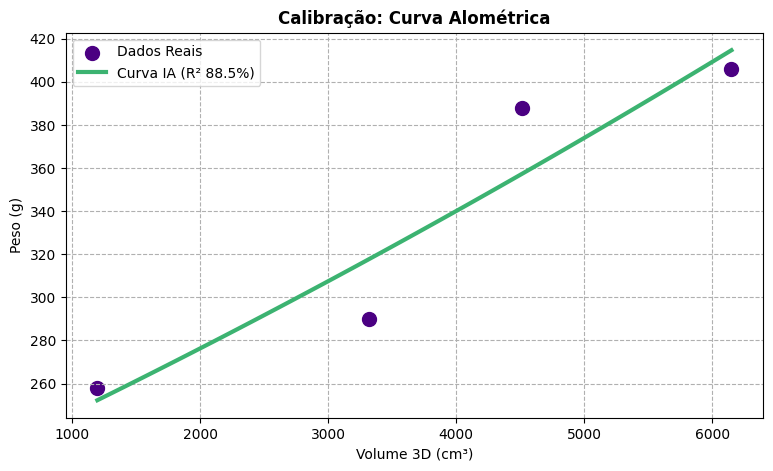

In [30]:
# @title 📊 1. Alimentar Banco de Dados (Treinar I.A.)
# @markdown Este bloco processa os vídeos das pastas `leve`, `media` e `pesada`, treina a curva de crescimento biológico e guarda o modelo.

import os
import glob
import re
import pyrealsense2 as rs
import numpy as np
import cv2
from ultralytics import YOLO
from scipy.spatial import ConvexHull
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import joblib

# Silenciar os avisos longos do YOLO
import logging
logging.getLogger("ultralytics").setLevel(logging.ERROR)

print("A carregar o modelo de Visão Computacional (YOLOv8)...")
modelo_yolo = YOLO('yolov8n-seg.pt')

# Caminhos locais
pastas_categorias = ['/content/leve', '/content/media', '/content/pesada']
dataset_treino = []

def extrair_volume_alta_precisao(caminho_bag):
    pipeline = rs.pipeline()
    config = rs.config()
    try:
        rs.config.enable_device_from_file(config, caminho_bag, repeat_playback=False)
        profile = pipeline.start(config)
    except Exception as e:
        return None

    for _ in range(15): pipeline.wait_for_frames()
    depth_stream = profile.get_stream(rs.stream.depth).as_video_stream_profile()
    intrinsics = depth_stream.get_intrinsics()
    volumetrias_frame = []
    contador = 0

    try:
        while True:
            try:
                frames = pipeline.wait_for_frames(timeout_ms=1000)
            except RuntimeError:
                break

            color_frame = frames.get_color_frame()
            depth_frame = frames.get_depth_frame()
            if not color_frame or not depth_frame: continue

            if contador % 10 == 0 and len(volumetrias_frame) < 30:
                imagem = np.asanyarray(color_frame.get_data())
                resultados = modelo_yolo(imagem, classes=[14], verbose=False)

                if resultados[0].masks is not None:
                    mascara_tensor = resultados[0].masks.data[0].cpu().numpy()
                    mascara = cv2.resize(mascara_tensor, (imagem.shape[1], imagem.shape[0]))
                    mascara_binaria = (mascara > 0.5)

                    pontos_3d = []
                    h_m, w_m = mascara_binaria.shape
                    for v in range(0, h_m, 4):
                        for u in range(0, w_m, 4):
                            if mascara_binaria[v, u]:
                                z = depth_frame.get_distance(u, v)
                                if 0.2 < z < 2.0:
                                    x, y, z_pt = rs.rs2_deproject_pixel_to_point(intrinsics, [u, v], z)
                                    pontos_3d.append([x, y, z_pt])

                    if len(pontos_3d) > 50:
                        pontos_3d = np.array(pontos_3d) * 100
                        limite_chao = np.percentile(pontos_3d[:, 1], 90)
                        pontos_filtrados = pontos_3d[pontos_3d[:, 1] < limite_chao]
                        limite_profundidade = np.percentile(pontos_filtrados[:, 2], 95)
                        pontos_filtrados = pontos_filtrados[pontos_filtrados[:, 2] < limite_profundidade]

                        if len(pontos_filtrados) > 20:
                            try:
                                hull = ConvexHull(pontos_filtrados)
                                volumetrias_frame.append(hull.volume)
                            except:
                                pass
            contador += 1
            if len(volumetrias_frame) >= 30: break
    finally:
        pipeline.stop()

    return np.median(volumetrias_frame) if len(volumetrias_frame) >= 5 else None

# Processar os ficheiros
for pasta in pastas_categorias:
    if os.path.exists(pasta):
        for caminho in glob.glob(os.path.join(pasta, '*.bag')):
            if os.path.getsize(caminho) / (1024 * 1024) > 1.0:
                nums = re.findall(r'\d+', os.path.basename(caminho))
                if nums: dataset_treino.append({"ficheiro": caminho, "peso_real": float(nums[-1])})

if len(dataset_treino) < 3:
    print("⚠ ERRO: Adicione vídeos às pastas '/content/leve', '/content/media', ou '/content/pesada'.")
else:
    print(f"\nA extrair geometria 3D de {len(dataset_treino)} vídeos. Por favor, aguarde...")
    volumes_extraidos, pesos_reais = [], []
    for item in dataset_treino:
        vol = extrair_volume_alta_precisao(item['ficheiro'])
        if vol:
            volumes_extraidos.append([vol])
            pesos_reais.append(item["peso_real"])

    if len(volumes_extraidos) >= 3:
        X, y = np.array(volumes_extraidos), np.array(pesos_reais)
        modelo_ml = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
        modelo_ml.fit(X, y)

        # GUARDAR O MODELO PARA USO FUTURO
        joblib.dump(modelo_ml, 'modelo_zootecnico.pkl')

        r2 = r2_score(y, modelo_ml.predict(X))
        print("\n" + "★"*50)
        print(f" BASE DE DADOS ALIMENTADA COM SUCESSO!")
        print(f" Precisão do Modelo Polinomial (R²): {r2*100:.1f}%")
        print(f" O modelo foi guardado como 'modelo_zootecnico.pkl'.")
        print("★"*50)

        plt.figure(figsize=(9, 5))
        plt.scatter(X, y, color='indigo', s=100, label='Dados Reais')
        x_range = np.linspace(min(X), max(X), 100).reshape(-1, 1)
        plt.plot(x_range, modelo_ml.predict(x_range), color='mediumseagreen', linewidth=3, label=f'Curva IA (R² {r2*100:.1f}%)')
        plt.title('Calibração: Curva Alométrica', fontweight='bold')
        plt.xlabel('Volume 3D (cm³)')
        plt.ylabel('Peso (g)')
        plt.legend()
        plt.grid(True, linestyle='--')
        plt.show()

In [34]:
# @title ⚖️ 2. Verificar Peso (Testar Nova Galinha)
# @markdown Escreva o nome do vídeo abaixo e clique no botão de Play desta célula.
nome_do_video_novo = "/content/leve/LEVE 10 - 258.bag" # @param {type:"string"}

import os
import numpy as np
import joblib

if not os.path.exists('modelo_zootecnico.pkl'):
    print("❌ Erro: O modelo ainda não foi treinado! Rode a aba 'Alimentar Banco de Dados' primeiro.")
elif not os.path.exists(nome_do_video_novo):
    print(f"❌ Erro: O vídeo '{nome_do_video_novo}' não foi encontrado. Verifique se o upload terminou.")
else:
    print(f"🔍 A analisar a estrutura 3D de: {os.path.basename(nome_do_video_novo)}...")

    # Carregar a IA treinada anteriormente
    modelo_ml = joblib.load('modelo_zootecnico.pkl')

    # A função extrair_volume_alta_precisao fica na memória se rodou a Célula 1 hoje.
    volume_novo = extrair_volume_alta_precisao(nome_do_video_novo)

    if volume_novo:
        X_novo = np.array([[volume_novo]])
        peso_previsto = modelo_ml.predict(X_novo)[0]

        print("\n" + "="*50)
        print("🎯 RESULTADO DA PREVISÃO:")
        print(f" • Volume 3D da Ave: {volume_novo:.1f} cm³")
        print(f" • Peso Estimado na Balança: {peso_previsto:.1f} gramas")
        print("="*50)
    else:
        print("❌ Não foi possível extrair a geometria desta ave. Tente outro vídeo.")

🔍 A analisar a estrutura 3D de: LEVE 10 - 258.bag...

🎯 RESULTADO DA PREVISÃO:
 • Volume 3D da Ave: 1201.0 cm³
 • Peso Estimado na Balança: 252.4 gramas
